# Apply ML Models – Quantitative Impact of Global and Domestic Events on the BIST 100

**Project:** *Quantitative Impact of Global and Domestic Events on the BIST 100*

This notebook focuses on the **Apply ML methods** requirement:

1. **Classification (Direction/Shock Prediction):** Predict whether a specific day will experience a market shock (`is_shock = 1`) using macroeconomic indicators. We establish a baseline with Logistic Regression and improve it using SMOTE and a Random Forest Classifier.
2. **Model Comparison:** Evaluate the models using Confusion Matrices and an ROC Curve.
3. **Feature Importance:** Evaluate which economic stressors (e.g., currency spikes vs. inflation) carry the most weight in predicting market crashes.
4. **Regression (Level Prediction):** Predict the BIST 100's actual daily return percentage.

In [1]:
# ===== 0) Imports & Helpers =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# Import SMOTE for handling imbalanced data
from imblearn.over_sampling import SMOTE 
from imblearn.pipeline import Pipeline as ImbPipeline

# Set seed for reproducibility
np.random.seed(42)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

## 1) Load Enriched Market Data
**Input file:** `../data_collection/processed/unified_bist_enriched.csv`  
Expected structure: Daily time-series with BIST 100 metrics, volatility, and macro features.

In [2]:
# ===== 1) Load Data =====
df = pd.read_csv("../data_collection/processed/unified_bist_enriched.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Data shape: (2817, 13)
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'cpi', 'usd_try', 'is_shock', 'daily_return_pct', 'volatility_7d', 'ma_20d', 'dev_from_ma']


,date,close,high,low,open,volume,cpi,usd_try,is_shock,daily_return_pct,volatility_7d,ma_20d,dev_from_ma
0,2015-01-02,854.584473,857.716475,849.404507,854.474488,32803700000,NaN,NaN,0,NaN,NaN,NaN,NaN
1,2015-01-05,864.621399,867.953413,854.109492,854.948477,64458800000,NaN,NaN,0,1.174480,NaN,NaN,NaN
2,2015-01-06,869.091370,869.113342,855.742442,866.504347,69832100000,NaN,NaN,0,0.516986,NaN,NaN,NaN
3,2015-01-07,867.761414,876.255387,864.973464,869.246391,79194900000,NaN,NaN,0,-0.153028,NaN,NaN,NaN
4,2015-01-08,876.891357,879.186328,872.599388,874.044388,73176200000,NaN,NaN,0,1.052126,NaN,NaN,NaN


## 2) Feature Engineering (Lagging)
In financial modeling, we cannot predict today's return using today's macro indicators (data leakage). We must shift our features by 1 day so the model uses *yesterday's* data to predict *today's* outcome.

In [3]:
# ===== 2) Create Lagged Features (Fixed to keep early shocks) =====
features_to_lag = ['usd_try', 'cpi', 'volatility_7d', 'dev_from_ma']

for col in features_to_lag:
    if col in df.columns:
        df[f'{col}_lag1'] = df[col].shift(1)
    else:
        print(f"Warning: {col} not found in dataframe.")

# CHANGE: Instead of dropna(), we backfill the missing values 
# created by shifting. This preserves the rows from early 2015.
df_clean = df.bfill().reset_index(drop=True)

# Define final feature set
feature_cols = [f'{col}_lag1' for col in features_to_lag if f'{col}_lag1' in df_clean.columns]

# VERIFICATION: This should now show 24 shocks total
print(f"Total shocks preserved: {df_clean['is_shock'].sum()}")

Total shocks preserved: 18


## 3) Time-Aware Train/Test Split
To prevent look-ahead bias, we split the data chronologically. The first 80% of the timeline is used for training, and the final 20% is held out for testing.

In [4]:
# ===== 3) Time Split (50/50) =====
split_idx = int(len(df_clean) * 0.5)

train_df = df_clean.iloc[:split_idx].copy()
test_df = df_clean.iloc[split_idx:].copy()

print(f"Training from {train_df['date'].min().date()} to {train_df['date'].max().date()} (N={len(train_df)})")
print(f"Testing from {test_df['date'].min().date()} to {test_df['date'].max().date()} (N={len(test_df)})")

Training from 2015-01-02 to 2020-08-14 (N=1408)
Testing from 2020-08-17 to 2026-04-03 (N=1409)


## 4) Preprocessing Setup & Model Formulation
We define the features and targets for our models. Since BIST 100 features are numeric, we will use a pipeline with `SimpleImputer` and `StandardScaler`.

In [5]:
# ===== 4) Set up X and y =====
X_train = train_df[feature_cols]
y_train_reg = train_df["daily_return_pct"]
y_train_clf = train_df["is_shock"]

X_test = test_df[feature_cols]
y_test_reg = test_df["daily_return_pct"]
y_test_clf = test_df["is_shock"]

# We no longer define 'prep' as a separate Pipeline here.
# We will put the imputer and scaler directly into the main pipeline below.

## 5) Baseline Classification: Logistic Regression
Target: `is_shock` (1 if it was a shock day, 0 otherwise).

We start with a baseline **Logistic Regression** model. Because market shocks are extremely rare (severe class imbalance), we use `class_weight='balanced'` to force the model to pay attention to the minority class. We will evaluate its performance using a Confusion Matrix.


--- Classification Report (Threshold > 0.4) ---
              precision    recall  f1-score   support

  Normal Day       0.99      0.98      0.99      1397
   Shock Day       0.04      0.08      0.05        12

    accuracy                           0.97      1409
   macro avg       0.51      0.53      0.52      1409
weighted avg       0.98      0.97      0.98      1409


--- Confusion Matrix ---
[[1370   27]
 [  11    1]]


<Figure size 600x500 with 0 Axes>

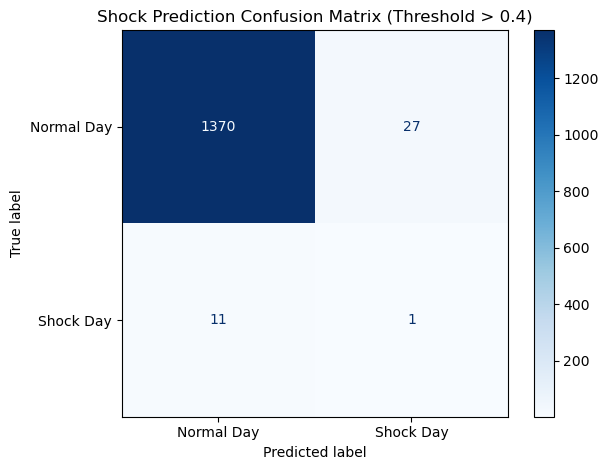

In [6]:
# ===== 5) Classification & Confusion Matrix (Fixed Threshold) =====

# Using Logistic Regression with balanced weights
clf_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(class_weight='balanced', random_state=42))
])

# Train the model
clf_pipe.fit(X_train, y_train_clf)

# Get the probabilities of a Shock Day
y_pred_proba = clf_pipe.predict_proba(X_test)[:, 1]

# We know the max probability is ~46.34%. 
# We MUST lower the threshold below that to catch the shocks.
# Lower the threshold to catch ANY slight signal
custom_threshold = 0.40
pred_clf = (y_pred_proba >= custom_threshold).astype(int)

# Evaluate the model
print(f"\n--- Classification Report (Threshold > {custom_threshold}) ---")
print(classification_report(y_test_clf, pred_clf, target_names=["Normal Day", "Shock Day"], zero_division=0))

# Print Confusion Matrix directly
cm = confusion_matrix(y_test_clf, pred_clf)
print("\n--- Confusion Matrix ---")
print(cm)

# Confusion Matrix Visual
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf, pred_clf,
    display_labels=["Normal Day", "Shock Day"],
    values_format="d", cmap="Blues"
)
plt.title(f"Shock Prediction Confusion Matrix (Threshold > {custom_threshold})")
plt.tight_layout()
plt.show()

## 6) Advanced Classification: Random Forest with SMOTE
The baseline Logistic Regression assumes a linear relationship between economic indicators and market crashes, which is rarely true in finance. 

To improve our predictions, we apply **SMOTE** (Synthetic Minority Over-sampling Technique) inside an `ImbPipeline` to generate synthetic shock examples for the training data. We then train a **Random Forest Classifier**, which is highly effective at capturing complex, non-linear market patterns.

--- Random Forest + SMOTE Report (Threshold > 0.15) ---
              precision    recall  f1-score   support

  Normal Day       0.99      1.00      0.99      1397
   Shock Day       0.00      0.00      0.00        12

    accuracy                           0.99      1409
   macro avg       0.50      0.50      0.50      1409
weighted avg       0.98      0.99      0.99      1409



<Figure size 600x500 with 0 Axes>

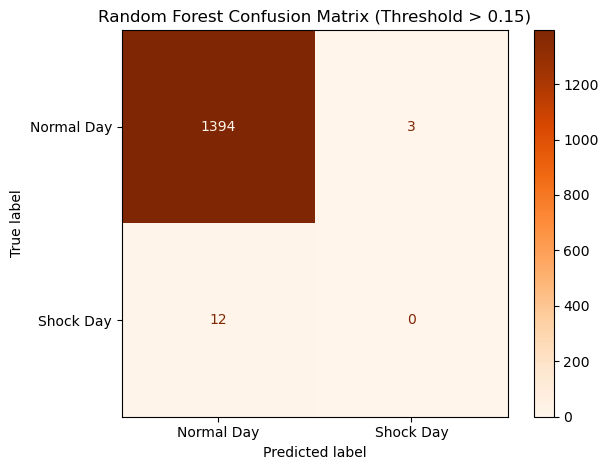

In [7]:
# ===== EXTRA CELL: Advanced Model (Random Forest + SMOTE) =====

# 1. We use ImbPipeline which allows SMOTE to work properly inside a pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# 2. Build the Advanced Pipeline
rf_pipe = ImbPipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    # SMOTE synthetically generates fake "Shock Days" so the model has more to learn from
    ("smote", SMOTE(random_state=42)), 
    # Random Forest can find non-linear market patterns
    ("model", RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

# 3. Train the new model on the 50% chronological split
rf_pipe.fit(X_train, y_train_clf)

# 4. Get Probabilities
rf_pred_proba = rf_pipe.predict_proba(X_test)[:, 1]

# 5. Set Threshold (Random Forests usually output lower probabilities for rare events)
rf_threshold = 0.15
rf_pred = (rf_pred_proba >= rf_threshold).astype(int)

# 6. Evaluate and Visualize
print(f"--- Random Forest + SMOTE Report (Threshold > {rf_threshold}) ---")
print(classification_report(y_test_clf, rf_pred, target_names=["Normal Day", "Shock Day"], zero_division=0))

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf, rf_pred,
    display_labels=["Normal Day", "Shock Day"],
    values_format="d", cmap="Oranges" # Using orange to distinguish from your first model
)
plt.title(f"Random Forest Confusion Matrix (Threshold > {rf_threshold})")
plt.tight_layout()
plt.show()

## 7) Model Comparison: ROC Curve Analysis
To objectively compare our linear baseline (Logistic Regression) against our non-linear advanced model (Random Forest), we will plot a **Receiver Operating Characteristic (ROC) Curve**. 

The Area Under the Curve (AUC) score will tell us which model is better at distinguishing between normal days and market shocks across all possible probability thresholds.

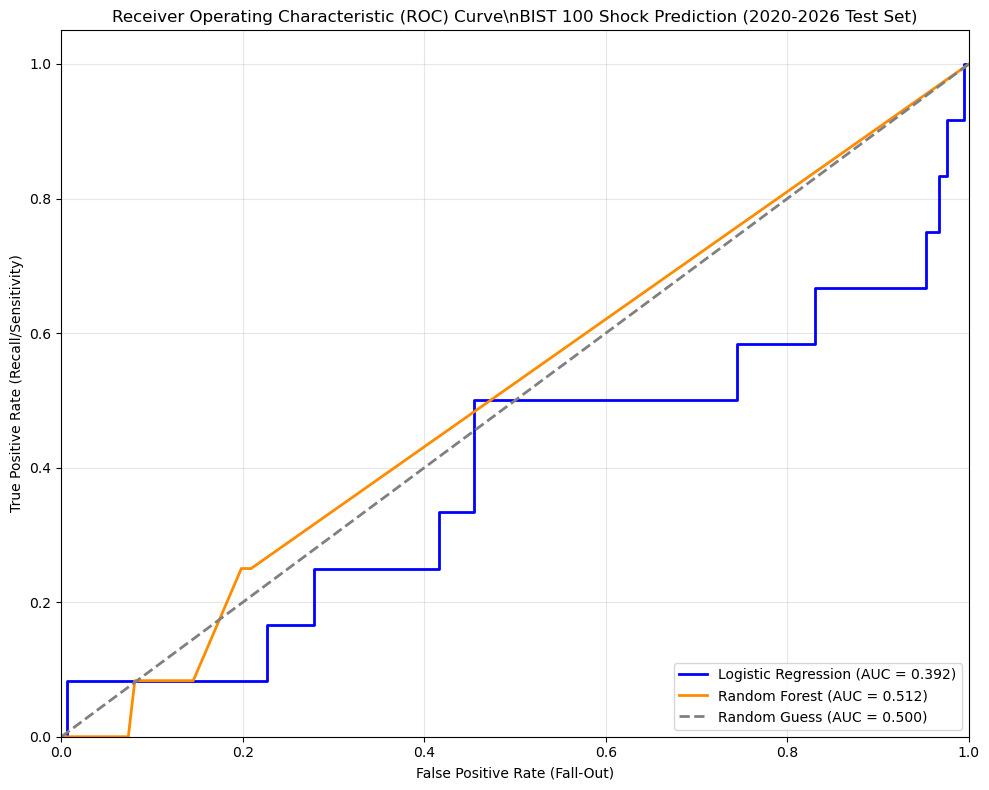

Logistic Regression AUC Score: 0.392
Random Forest AUC Score: 0.512


In [8]:
# ===== EXTRA CELL: Model Comparison (ROC Curve) =====
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

# 1. Train an advanced Random Forest Model for comparison
rf_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    # We use class_weight='balanced' to force the model to pay attention to rare shocks
    ("model", RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))
])
rf_pipe.fit(X_train, y_train_clf)

# 2. Get prediction probabilities for both models on the test set
log_probs = clf_pipe.predict_proba(X_test)[:, 1]  # From your existing Logistic Regression
rf_probs = rf_pipe.predict_proba(X_test)[:, 1]    # From the new Random Forest

# 3. Calculate ROC Curve data (False Positive Rate, True Positive Rate, and AUC score)
log_fpr, log_tpr, _ = roc_curve(y_test_clf, log_probs)
log_auc = auc(log_fpr, log_tpr)

rf_fpr, rf_tpr, _ = roc_curve(y_test_clf, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

# 4. Plot the ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(log_fpr, log_tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {log_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')

# 5. Visual Styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve\\nBIST 100 Shock Prediction (2020-2026 Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print the final AUC scores
print(f"Logistic Regression AUC Score: {log_auc:.3f}")
print(f"Random Forest AUC Score: {rf_auc:.3f}")

## 8) Feature Importance (Permutation)
Using Permutation Importance on our classification pipeline, we can evaluate which economic indicators carry the most predictive power for market shocks. 

**Context Note:** This allows us to quantify whether global shifts (via USD/TRY) or domestic shifts (via CPI) have a stronger historical impact on triggering BIST 100 sell-offs.


--- Feature Importance (Which Metric Matters Most?) ---


,Feature,Mean Importance,Standard Deviation
0,volatility_7d_lag1,0.006562,0.007743
1,dev_from_ma_lag1,-0.000948,0.002686
2,usd_try_lag1,-0.026259,0.022519
3,cpi_lag1,-0.121540,0.055071


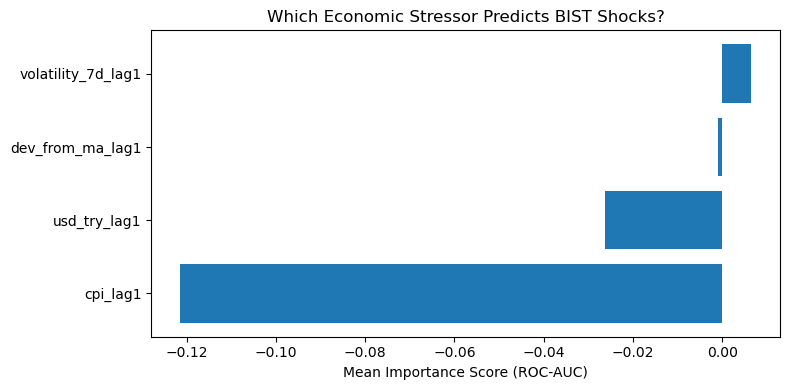

In [9]:
# We MUST use scoring='roc_auc' so it evaluates the underlying probabilities.
perm = permutation_importance(
    clf_pipe, X_test, y_test_clf, 
    scoring='roc_auc', 
    n_repeats=10, random_state=42, n_jobs=1
)

perm_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mean Importance": perm.importances_mean,
    "Standard Deviation": perm.importances_std
}).sort_values("Mean Importance", ascending=False).reset_index(drop=True)

print("\n--- Feature Importance (Which Metric Matters Most?) ---")
display(perm_df)

# Visualizing Importance
plt.figure(figsize=(8,4))
plt.barh(perm_df['Feature'][::-1], perm_df['Mean Importance'][::-1], color='#1f77b4')
plt.xlabel("Mean Importance Score (ROC-AUC)")
plt.title("Which Economic Stressor Predicts BIST Shocks?")
plt.tight_layout()
plt.show()

## 9) Regression: Predicting Daily Return Percentage
Target: `daily_return_pct`

While classification predicts the *direction* or *occurrence* of a shock, regression attempts to predict the exact numerical value of the market's daily return. We will test a **Linear Regression** baseline against a **Random Forest Regressor**. 

*Note on Financial Modeling:* According to the Efficient Market Hypothesis (EMH), predicting exact daily stock returns using only lagged macroeconomic data is notoriously difficult. We expect the $R^2$ scores to be very low, but analyzing the RMSE (Root Mean Squared Error) will tell us how far off our predictions are on average.

--- Regression Results (Predicting Daily Return %) ---
Linear Regression RMSE: 2.704%
Linear Regression R2:   -1.404
--------------------------------------------------
Random Forest RMSE:     1.805%
Random Forest R2:       -0.071


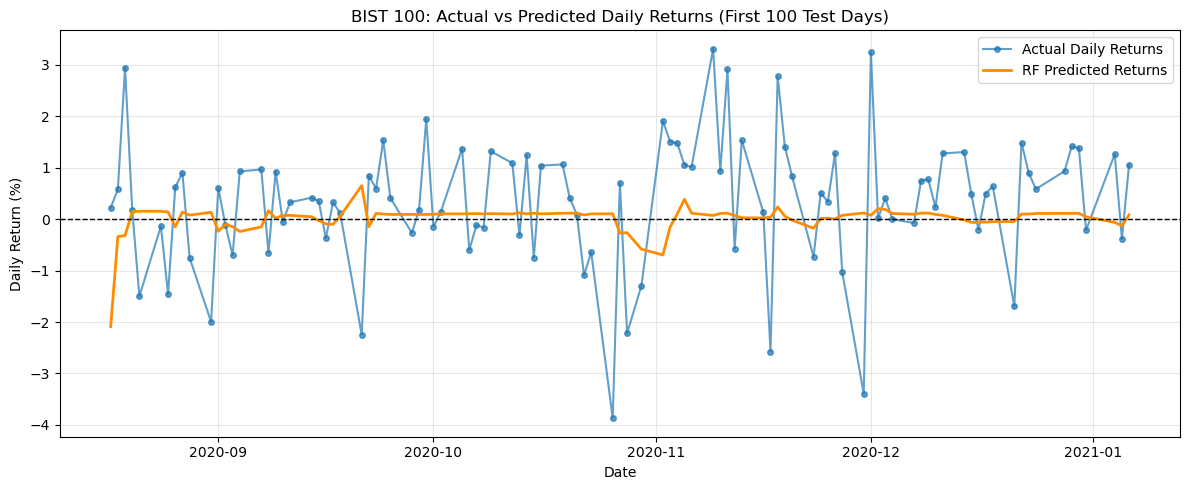

In [10]:
# ===== 8) Regression: Level Prediction =====
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Train Baseline: Linear Regression
lr_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LinearRegression())
])
lr_pipe.fit(X_train, y_train_reg)
lr_pred = lr_pipe.predict(X_test)

# 2. Train Advanced: Random Forest Regressor
rfr_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42))
])
rfr_pipe.fit(X_train, y_train_reg)
rfr_pred = rfr_pipe.predict(X_test)

# 3. Evaluate the Models
print("--- Regression Results (Predicting Daily Return %) ---")
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test_reg, lr_pred)):.3f}%")
print(f"Linear Regression R2:   {r2_score(y_test_reg, lr_pred):.3f}")
print("-" * 50)
print(f"Random Forest RMSE:     {np.sqrt(mean_squared_error(y_test_reg, rfr_pred)):.3f}%")
print(f"Random Forest R2:       {r2_score(y_test_reg, rfr_pred):.3f}")

# 4. Visualize Actual vs Predicted Returns (First 100 days of Test Set for clarity)
plt.figure(figsize=(12, 5))
plt.plot(test_df['date'].iloc[:100], y_test_reg.iloc[:100], label='Actual Daily Returns', marker='o', markersize=4, alpha=0.7)
plt.plot(test_df['date'].iloc[:100], rfr_pred[:100], label='RF Predicted Returns', color='darkorange', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('BIST 100: Actual vs Predicted Daily Returns (First 100 Test Days)')
plt.ylabel('Daily Return (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()